<h2 style="text-align:center;font-size:200%;;">IoT Temperature Forecasting</h2>
<h3  style="text-align:center;">Keywords : <span class="label label-success">IoT</span> <span class="label label-success">Time Series Analysis</span> <span class="label label-success">Pre-processing</span> <span class="label label-success">EDA</span> <span class="label label-success">Bayesian Modeling</span></h3>

# Table of Contents<a id='top'></a>

>1. [Overview](#1.-Overview)  
>   * [Project Detail](#Project-Detail)
>   * [Goal of this notebook](#Goal-of-this-notebook)
>1. [Import libraries](#2.-Import-libraries)
>1. [Load the dataset](#3.-Load-the-dataset)
>1. [Pre-processing](#4.-Pre-processing)
>   * [Datetime information](#Datetime-information)
>   * [Seasonal information](#Seasonal-information)
>   * [Timing information](#Timing-information)
>   * [Unique identifier defined by id](#Unique-identifier-defined-by-id)
>1. [EDA](#5.-EDA)  
>   * [Univariate Analysis](#Univariate-Analysis)
>   * [Multivariate Analysis](#Multivariate-Analysis)
>   * [Time Series Analysis](#Time-Series-Analysis)
>1. [Modelling](#6.-Modelling)
>    * [Data Preparation](#Data-Preparation)
>    * [Build Model & Predict Future Temperature](#Build-Model-&-Predict-Future-Temperature)
>1. [Conclusion](#7.-Conclusion)
>    * [Task Submission](#Task-Submission)
>1. [References](#8.-References)

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

# 1. Overview
## Project Detail
><p>In <a href='https://www.kaggle.com/atulanandjha/temperature-readings-iot-devices'>this Dataset</a>, we have the temperature readings from IoT devices installed outside and inside of an anonymous room. Because the device was in the testing phase, it was uninstalled or shut off several times during the entire reading period, which caused some outliers and missing-values.</p><br/>
>Dataset details:
><ul>
>    <li><b>id</b> : unique IDs for each reading</li>
>    <li><b>room_id/id</b> : room id in which device was installed(currently 'admin room' only for example purpose).</li>
>    <li><b>noted_date</b> : date and time of reading</li>
>    <li><b>temp</b> : temperature readings</li>
>    <li><b>out/in</b> : whether reading was taken from device installed inside or outside of room</li>
></ul>
>We can enjoy finding out the following:
><ul>
>    <li>the relationship of inside and outside temperature</li>
>    <li>trend or seasonality in the data</li>
>    <li>forecasting future temperature by using time-series modeling</li>
>    <li>characteristic tendency through year, month, week or day/night</li>
>    <li>and so on...</li>
></ul>

## Goal of this notebook
>* Practice data cleansing technique
>* Practice EDA technique to deal with time-series data
>    * Series Decomposition into trend/seasonality
>* Practice visualising technique
>* Practice time-series modeling technique
>    * Prophet

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

# 2. Import libraries

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
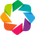

In [1]:
import numpy as np
import pandas as pd
import holoviews as hv
from holoviews import opts
hv.extension('bokeh')
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
!pip install prophet
from prophet import Prophet

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

# 3. Load the dataset

In [2]:
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
from google.colab import files
uploaded = files.upload()

Saving IOT-temp.csv.zip to IOT-temp.csv (1).zip
Saving IOT-temp.ipynb to IOT-temp (2).ipynb


<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

# 4. Pre-processing

>column 'room_id/id' has only one value(Room Admin), so we don't need this column for analysis.

In [4]:
import os
print(os.listdir())

['.config', 'IOT-temp.ipynb', 'IOT-temp (1).ipynb', 'IOT-temp.csv (1).zip', 'IOT-temp (2).ipynb', 'IOT-temp.csv.zip', 'sample_data']


In [5]:
import pandas as pd

df = pd.read_csv("IOT-temp.csv.zip")
print(df.shape)
df.head()

(97606, 5)


,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In


In [6]:
df.drop('room_id/id', axis=1, inplace=True)
df.head(3)

,id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,08-12-2018 09:29,41,Out


>changing column names to understand easily

In [7]:
df.rename(columns={'noted_date':'date', 'out/in':'place'}, inplace=True)
df.head(3)

,id,date,temp,place
0,__export__.temp_log_196134_bd201015,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,08-12-2018 09:29,41,Out


<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

## Datetime information
>datetime column has a lot of information such as year, month, weekday and so on. To utilize these information in EDA and modeling phase, we need extract them from datetime column.

In [8]:
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y %H:%M')
df['year'] = df['date'].apply(lambda x : x.year)
df['month'] = df['date'].apply(lambda x : x.month)
df['day'] = df['date'].apply(lambda x : x.day)
df['weekday'] = df['date'].apply(lambda x : x.day_name())
df['weekofyear'] = df['date'].apply(lambda x : x.weekofyear)
df['hour'] = df['date'].apply(lambda x : x.hour)
df['minute'] = df['date'].apply(lambda x : x.minute)
df.head(3)

,id,date,temp,place,year,month,day,weekday,weekofyear,hour,minute
0,__export__.temp_log_196134_bd201015,2018-12-08 09:30:00,29,In,2018,12,8,Saturday,49,9,30
1,__export__.temp_log_196131_7bca51bc,2018-12-08 09:30:00,29,In,2018,12,8,Saturday,49,9,30
2,__export__.temp_log_196127_522915e3,2018-12-08 09:29:00,41,Out,2018,12,8,Saturday,49,9,29


<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

## Seasonal information
><div class="alert alert-success" role="alert">
>Let's assume this data was collected in India.<br/>
>According to <a href='https://en.wikipedia.org/wiki/Climate_of_India#Seasons'>this wiki page</a>, India has four climatological seasons as below.
><ul>
>    <li><b>Winter</b> : December to February</li>
>    <li><b>Summer</b> : March to May</li>
>    <li><b>Monsoon</b> : June to September</li>
>    <li><b>Post-monsoon</b> : October to November</li>
></ul>
>We can create seasonal variable based on month variable.<br/>
><u>The idea came from <a href='https://www.kaggle.com/satishkundanagar/temp-reading-iot-devices-eda'>this notebook.</a></u>
></div>

>function to convert month variable into seasons

In [9]:
def month2seasons(x):
    if x in [12, 1, 2]:
        season = 'Winter'
    elif x in [3, 4, 5]:
        season = 'Summer'
    elif x in [6, 7, 8, 9]:
        season = 'Monsoon'
    elif x in [10, 11]:
        season = 'Post_Monsoon'
    return season

In [10]:
df['season'] = df['month'].apply(month2seasons)
df.head(3)

,id,date,temp,place,year,month,day,weekday,weekofyear,hour,minute,season
0,__export__.temp_log_196134_bd201015,2018-12-08 09:30:00,29,In,2018,12,8,Saturday,49,9,30,Winter
1,__export__.temp_log_196131_7bca51bc,2018-12-08 09:30:00,29,In,2018,12,8,Saturday,49,9,30,Winter
2,__export__.temp_log_196127_522915e3,2018-12-08 09:29:00,41,Out,2018,12,8,Saturday,49,9,29,Winter


<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

## Timing information
><div class="alert alert-success" role="alert">
>Hour variable can be broken into Night, Morning, Afternoon and Evening based on its number.
><ul>
>    <li><b>Night</b> : 22:00 - 23:59 / 00:00 - 03:59</li>
>    <li><b>Morning</b> : 04:00 - 11:59</li>
>    <li><b>Afternoon</b> : 12:00 - 16:59</li>
>    <li><b>Evening</b> : 17:00 - 21:59</li>
></ul>
>We can create timing variable based on hour variable.<br/>
><u>The idea came from <a href='https://www.kaggle.com/satishkundanagar/temp-reading-iot-devices-eda'>this notebook.</a></u>
></div>

In [11]:
def hours2timing(x):
    if x in [22,23,0,1,2,3]:
        timing = 'Night'
    elif x in range(4, 12):
        timing = 'Morning'
    elif x in range(12, 17):
        timing = 'Afternoon'
    elif x in range(17, 22):
        timing = 'Evening'
    else:
        timing = 'X'
    return timing

In [12]:
df['timing'] = df['hour'].apply(hours2timing)
df.head(3)

,id,date,temp,place,year,month,day,weekday,weekofyear,hour,minute,season,timing
0,__export__.temp_log_196134_bd201015,2018-12-08 09:30:00,29,In,2018,12,8,Saturday,49,9,30,Winter,Morning
1,__export__.temp_log_196131_7bca51bc,2018-12-08 09:30:00,29,In,2018,12,8,Saturday,49,9,30,Winter,Morning
2,__export__.temp_log_196127_522915e3,2018-12-08 09:29:00,41,Out,2018,12,8,Saturday,49,9,29,Winter,Morning


<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

## Unique identifier defined by id
><div class="alert alert-success" role="alert">
>Column 'id' seems to have some information related to 'date' column. <br/>
>Column 'date' doesn't have seconds information, so 'id' may have seconds information or some uniqueness of when the data was collected.<br/>
><u>The idea came from <a href='https://www.kaggle.com/satishkundanagar/temp-reading-iot-devices-eda'>this notebook.</a></u>
></div>

### Duplication
>After checking whether any record is duplicated, it turned out that there were duplicate records. So we need to put duplicate records into one unique record.

In [13]:
df[df.duplicated()]

,id,date,temp,place,year,month,day,weekday,weekofyear,hour,minute,season,timing
11,__export__.temp_log_196108_4a983c7e,2018-12-08 09:25:00,42,Out,2018,12,8,Saturday,49,9,25,Winter,Morning


In [14]:
df[df['id']=='__export__.temp_log_196108_4a983c7e']

,id,date,temp,place,year,month,day,weekday,weekofyear,hour,minute,season,timing
10,__export__.temp_log_196108_4a983c7e,2018-12-08 09:25:00,42,Out,2018,12,8,Saturday,49,9,25,Winter,Morning
11,__export__.temp_log_196108_4a983c7e,2018-12-08 09:25:00,42,Out,2018,12,8,Saturday,49,9,25,Winter,Morning


In [15]:
df.drop_duplicates(inplace=True)
df[df.duplicated()]

,id,date,temp,place,year,month,day,weekday,weekofyear,hour,minute,season,timing


<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

### Uniqueness of id
><div class="alert alert-success" role="alert">
>Looking closely at 'id' column, it seemed to have unique values and two decomposable components, numeric and alpha-numeric.<br/>
>In the case of 'id' of <b>'__export__.temp_log_101144_ff2f0b97'</b>, it can be decomposed into two parts.
><ul>
>    <li><b>numeric part</b> : 101144</li>
>    <li><b>alpha-numeric part</b> : ff2f0b97</li>
></ul>
>Alpha-numeric part looks impossible to understand, but <u>numeric part may indicate <b>uniqueness</b> or <b>sortability</b> of each records, for example seconds information</u>.
></div>

>In the same datetime(<b>2018-09-12 03:09:00</b>), there are many records and unique ids.

In [16]:
df.loc[df['date']=='2018-09-12 03:09:00', ].sort_values(by='id').head(5)

,id,date,temp,place,year,month,day,weekday,weekofyear,hour,minute,season,timing
61229,__export__.temp_log_101144_ff2f0b97,2018-09-12 03:09:00,29,Out,2018,9,12,Wednesday,37,3,9,Monsoon,Night
61258,__export__.temp_log_101502_172517d2,2018-09-12 03:09:00,29,In,2018,9,12,Wednesday,37,3,9,Monsoon,Night
61255,__export__.temp_log_104868_a5e526b3,2018-09-12 03:09:00,28,In,2018,9,12,Wednesday,37,3,9,Monsoon,Night
61231,__export__.temp_log_108845_062b2592,2018-09-12 03:09:00,28,In,2018,9,12,Wednesday,37,3,9,Monsoon,Night
61272,__export__.temp_log_112303_fca608f4,2018-09-12 03:09:00,29,In,2018,9,12,Wednesday,37,3,9,Monsoon,Night


>The count of numeric parts in 'id' have the same number as the length of the entire data, so the numeric parts indicate uniqueness of each records.

In [17]:
df['id'].apply(lambda x : x.split('_')[6]).nunique() == len(df)

True

>Adding numeric parts in 'id' as new identifier.

In [18]:
df['id'] = df['id'].apply(lambda x : int(x.split('_')[6]))
df.head(3)

,id,date,temp,place,year,month,day,weekday,weekofyear,hour,minute,season,timing
0,196134,2018-12-08 09:30:00,29,In,2018,12,8,Saturday,49,9,30,Winter,Morning
1,196131,2018-12-08 09:30:00,29,In,2018,12,8,Saturday,49,9,30,Winter,Morning
2,196127,2018-12-08 09:29:00,41,Out,2018,12,8,Saturday,49,9,29,Winter,Morning


<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

### Gaps in id
><div class="alert alert-success" role="alert">
>Selecting one unique datetime(<b>2018-09-12 03:09:00</b>) and sorting by 'id', it turned out that there were <u>some gaps</u> in 'id' column.<br/>
>This fact makes it little difficult to understand mapping of 'id' to 'date'.
><ul>
>    <li><b>17003 - 17006</b> : 17004 and 17005 missing</li>
>    <li><b>17006 - 17009</b> : 17007 and 17008 missing</li>
></ul>
>On the other hand, selecting certain range of 'id'(<b>4000-4010</b>) and sorting by its number, it turned out that there was <u>a gap in 'date' between 'id' 4004 and the others</u>.<br/>
>Sorting by 'id', it must have orderliness in 'date'. But <u>in 'id' 4004 'date' have former datetime compared to the previous 'id'</u>.
><ul>
>    <li><b>4002</b> : 2018-09-09 16:<font color='red'>24</font>:00</li>
>    <li><b>4004</b> : 2018-09-09 16:<font color='red'>23</font>:00</li>
></ul>
>So it can be said that <u>'id' column is not related to second information, but it can be used as <b>a unique identifier</b> of each records</u>.
></div>

>There are gaps in 'id' column.

In [19]:
df.loc[df['date'] == '2018-09-12 03:09:00', ].sort_values(by ='id').head(5)

,id,date,temp,place,year,month,day,weekday,weekofyear,hour,minute,season,timing
61273,17002,2018-09-12 03:09:00,29,Out,2018,9,12,Wednesday,37,3,9,Monsoon,Night
61275,17003,2018-09-12 03:09:00,28,Out,2018,9,12,Wednesday,37,3,9,Monsoon,Night
61267,17006,2018-09-12 03:09:00,28,Out,2018,9,12,Wednesday,37,3,9,Monsoon,Night
61269,17009,2018-09-12 03:09:00,28,Out,2018,9,12,Wednesday,37,3,9,Monsoon,Night
61271,17010,2018-09-12 03:09:00,29,Out,2018,9,12,Wednesday,37,3,9,Monsoon,Night


>There is a gap in 'date' column when ordered by 'id'.

In [20]:
df.loc[df['id'].isin(range(4000, 4011))].sort_values(by='id')

,id,date,temp,place,year,month,day,weekday,weekofyear,hour,minute,season,timing
84141,4000,2018-09-09 16:24:00,29,Out,2018,9,9,Sunday,36,16,24,Monsoon,Afternoon
84142,4002,2018-09-09 16:24:00,29,Out,2018,9,9,Sunday,36,16,24,Monsoon,Afternoon
84144,4004,2018-09-09 16:23:00,28,Out,2018,9,9,Sunday,36,16,23,Monsoon,Afternoon
84128,4006,2018-09-09 16:24:00,28,Out,2018,9,9,Sunday,36,16,24,Monsoon,Afternoon
84132,4007,2018-09-09 16:24:00,29,Out,2018,9,9,Sunday,36,16,24,Monsoon,Afternoon
84136,4009,2018-09-09 16:24:00,28,Out,2018,9,9,Sunday,36,16,24,Monsoon,Afternoon
84137,4010,2018-09-09 16:24:00,28,Out,2018,9,9,Sunday,36,16,24,Monsoon,Afternoon


<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

# 5. EDA

## Univariate Analysis

### Monthly Readings

In [21]:
month_rd = np.round(df['date'].apply(lambda x : x.strftime("%Y-%m")).value_counts(normalize=True).sort_index() * 100,decimals=1)
month_rd_bar = hv.Bars(month_rd).opts(color="green")
month_rd_curve = hv.Curve(month_rd).opts(color="red")
(month_rd_bar * month_rd_curve).opts(title="Monthly Readings Count", xlabel="Month", ylabel="Percentage", yformatter='%d%%', width=700, height=300,tools=['hover'],show_grid=True)

:Overlay
   .Bars.I  :Bars   [date]   (proportion)
   .Curve.I :Curve   [date]   (proportion)

### Temperature
>Temperature clearly consists of multiple distributions.

In [22]:
hv.Distribution(df['temp']).opts(title="Temperature Distribution", color="green", xlabel="Temperature", ylabel="Density")\
                            .opts(opts.Distribution(width=700, height=300,tools=['hover'],show_grid=True))

:Distribution   [temp]   (Density)

### Place

In [23]:
pl_cnt = np.round(df['place'].value_counts(normalize=True) * 100)
hv.Bars(pl_cnt).opts(title="Readings Place Count", color="green", xlabel="Places", ylabel="Percentage", yformatter='%d%%')\
                .opts(opts.Bars(width=700, height=300,tools=['hover'],show_grid=True))

:Bars   [place]   (proportion)

### Season

In [24]:
season_cnt = np.round(df['season'].value_counts(normalize=True) * 100)
hv.Bars(season_cnt).opts(title="Season Count", color="green", xlabel="Season", ylabel="Percentage", yformatter='%d%%')\
                .opts(opts.Bars(width=700, height=300,tools=['hover'],show_grid=True))

:Bars   [season]   (proportion)

### Timing

In [25]:
timing_cnt = np.round(df['timing'].value_counts(normalize=True) * 100)
hv.Bars(timing_cnt).opts(title="Timing Count", color="green", xlabel="Timing", ylabel="Percentage", yformatter='%d%%')\
                .opts(opts.Bars(width=700, height=300,tools=['hover'],show_grid=True))

:Bars   [timing]   (proportion)

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

## Multivariate Analysis

### Monthly Readings by Place

In [26]:
in_month = np.round(
    df[df['place'] == 'In']['date']
    .apply(lambda x: x.strftime("%Y-%m"))
    .value_counts(normalize=True)
    .sort_index() * 100,
    decimals=1
)

out_month = np.round(
    df[df['place'] == 'Out']['date']
    .apply(lambda x: x.strftime("%Y-%m"))
    .value_counts(normalize=True)
    .sort_index() * 100,
    decimals=1
)

in_out_month = pd.merge(
    in_month, out_month, left_index=True, right_index=True, how='outer'
).fillna(0)

in_out_month.columns = ['In', 'Out']
in_out_month.index.name = 'Month'

in_out_month = pd.melt(
    in_out_month.reset_index(),
    id_vars=['Month'],
    var_name='Place',
    value_name='value'
)

hv.Bars(in_out_month, ['Month', 'Place'], 'value').opts(
    opts.Bars(
        title="Monthly Readings by Place Count",
        width=700,
        height=400,
        tools=['hover'],
        show_grid=True,
        ylabel="Count"
    )
)

:Bars   [Month,Place]   (value)

### Temperature Distribution by Place
><div class="alert alert-success" role="alert">
><ul>
><li>Inside temperature is composed of a single distribution, while <u>outside temperature is composed of multiple distributions.</u></li>
><li>It seems that the temperature inside the room is kept constant by the air conditioner, but <u>the outside temperature is easily affected by time-series factors such as seasons.</u></li>
></ul>
></div>

In [27]:
(hv.Distribution(df[df['place']=='In']['temp'], label='In') * hv.Distribution(df[df['place']=='Out']['temp'], label='Out'))\
                                .opts(title="Temperature by Place Distribution", xlabel="Temperature", ylabel="Density")\
                                .opts(opts.Distribution(width=700, height=300,tools=['hover'],show_grid=True))

:Overlay
   .Distribution.In  :Distribution   [temp]   (Density)
   .Distribution.Out :Distribution   [temp]   (Density)

### Temperature by Season

In [28]:
season_agg = df.groupby('season').agg({'temp': ['min', 'max']})
season_maxmin = pd.merge(season_agg['temp']['max'],season_agg['temp']['min'],right_index=True,left_index=True)
season_maxmin = pd.melt(season_maxmin.reset_index(), ['season']).rename(columns={'season':'Season', 'variable':'Max/Min'})
hv.Bars(season_maxmin, ['Season', 'Max/Min'], 'value').opts(title="Temperature by Season Max/Min", ylabel="Temperature")\
                                                                    .opts(opts.Bars(width=700, height=300,tools=['hover'],show_grid=True))

:Bars   [Season,Max/Min]   (value)

### Temperature by Timing

In [29]:
timing_agg = df.groupby('timing').agg({'temp': ['min', 'max']})
timing_maxmin = pd.merge(timing_agg['temp']['max'],timing_agg['temp']['min'],right_index=True,left_index=True)
timing_maxmin = pd.melt(timing_maxmin.reset_index(), ['timing']).rename(columns={'timing':'Timing', 'variable':'Max/Min'})
hv.Bars(timing_maxmin, ['Timing', 'Max/Min'], 'value').opts(title="Temperature by Timing Max/Min", ylabel="Temperature")\
                                                                    .opts(opts.Bars(width=700, height=300,tools=['hover'],show_grid=True))

:Bars   [Timing,Max/Min]   (value)

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

## Time Series Analysis

### Pre-processing for time-series analysis
>It is easy to try time-series analysis with unique time-index data. So we need to calculate mean values by 'date' column and delete 'id' column.

In [30]:
tsdf = df.drop_duplicates(subset=['date','place']).sort_values('date').reset_index(drop=True)
tsdf['temp'] = df.groupby(['date','place'])['temp'].mean().values
tsdf.drop('id', axis=1, inplace=True)
tsdf.head(3)

,date,temp,place,year,month,day,weekday,weekofyear,hour,minute,season,timing
0,2018-07-28 07:06:00,31.0,In,2018,7,28,Saturday,30,7,6,Monsoon,Morning
1,2018-07-28 07:07:00,31.0,Out,2018,7,28,Saturday,30,7,7,Monsoon,Morning
2,2018-07-28 07:07:00,32.0,In,2018,7,28,Saturday,30,7,7,Monsoon,Morning


### Monthly Temperature Mean
><div class="alert alert-success" role="alert">
><ul>
><li>The <b>outside</b> temperature has a larger time series change than the <b>inside</b> temperature.</li>
><li>It is thought that the inside temperature is adjusted by air conditioner, but <u>the outside temperature is affected by seasonal temperature fluctuations.</u></li>
><ul>
></div>

In [31]:
in_month = tsdf[tsdf['place']=='In'].groupby('month').agg({'temp':['mean']})
in_month.columns = [f"{i[0]}_{i[1]}" for i in in_month.columns]
out_month = tsdf[tsdf['place']=='Out'].groupby('month').agg({'temp':['mean']})
out_month.columns = [f"{i[0]}_{i[1]}" for i in out_month.columns]
hv.Curve(in_month, label='In') * hv.Curve(out_month, label='Out').opts(title="Monthly Temperature Mean", ylabel="Temperature", xlabel='Month')\
                                                                    .opts(opts.Curve(width=700, height=300,tools=['hover'],show_grid=True))

:Overlay
   .Curve.In  :Curve   [month]   (temp_mean)
   .Curve.Out :Curve   [month]   (temp_mean)

### Daily Temperature Mean

In [32]:
tsdf['daily'] = tsdf['date'].apply(lambda x : pd.to_datetime(x.strftime('%Y-%m-%d')))
in_day = tsdf[tsdf['place']=='In'].groupby(['daily']).agg({'temp':['mean']})
in_day.columns = [f"{i[0]}_{i[1]}" for i in in_day.columns]
out_day = tsdf[tsdf['place']=='Out'].groupby(['daily']).agg({'temp':['mean']})
out_day.columns = [f"{i[0]}_{i[1]}" for i in out_day.columns]
(hv.Curve(in_day, label='In') * hv.Curve(out_day, label='Out')).opts(title="Daily Temperature Mean", ylabel="Temperature", xlabel='Day', shared_axes=False)\
                                                                    .opts(opts.Curve(width=700, height=300,tools=['hover'],show_grid=True))

:Overlay
   .Curve.In  :Curve   [daily]   (temp_mean)
   .Curve.Out :Curve   [daily]   (temp_mean)

### Weekday Temperature Mean

In [33]:
in_wd = tsdf[tsdf['place']=='In'].groupby('weekday').agg({'temp':['mean']})
in_wd.columns = [f"{i[0]}_{i[1]}" for i in in_wd.columns]
in_wd['week_num'] = [['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'].index(i) for i in in_wd.index]
in_wd.sort_values('week_num', inplace=True)
in_wd.drop('week_num', axis=1, inplace=True)
out_wd = tsdf[tsdf['place']=='Out'].groupby('weekday').agg({'temp':['mean']})
out_wd.columns = [f"{i[0]}_{i[1]}" for i in out_wd.columns]
out_wd['week_num'] = [['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'].index(i) for i in out_wd.index]
out_wd.sort_values('week_num', inplace=True)
out_wd.drop('week_num', axis=1, inplace=True)
hv.Curve(in_wd, label='In') * hv.Curve(out_wd, label='Out').opts(title="Weekday Temperature Mean", ylabel="Temperature", xlabel='Weekday')\
                                                                    .opts(opts.Curve(width=700, height=300,tools=['hover'],show_grid=True))

:Overlay
   .Curve.In  :Curve   [weekday]   (temp_mean)
   .Curve.Out :Curve   [weekday]   (temp_mean)

### WeekofYear Temperature Mean

In [34]:
in_wof = tsdf[tsdf['place']=='In'].groupby('weekofyear').agg({'temp':['mean']})
in_wof.columns = [f"{i[0]}_{i[1]}" for i in in_wof.columns]
out_wof = tsdf[tsdf['place']=='Out'].groupby('weekofyear').agg({'temp':['mean']})
out_wof.columns = [f"{i[0]}_{i[1]}" for i in out_wof.columns]
hv.Curve(in_wof, label='In') * hv.Curve(out_wof, label='Out').opts(title="WeekofYear Temperature Mean", ylabel="Temperature", xlabel='WeekofYear')\
                                                                    .opts(opts.Curve(width=700, height=300,tools=['hover'],show_grid=True))

:Overlay
   .Curve.In  :Curve   [weekofyear]   (temp_mean)
   .Curve.Out :Curve   [weekofyear]   (temp_mean)

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

### Missing data
><div class="alert alert-success" role="alert">
><ul>
><li>Plotting overall data, it is found that there are some missing data points randomly through whole period.</li>
><li>Interpolating with <b>'nearest'</b> method looks better(yet far from best), but there are many gaps in interpolated data yet.</li>
></ul>
></div>

In [35]:
in_tsdf = tsdf[tsdf['place']=='In'].reset_index(drop=True)
in_tsdf.index = in_tsdf['date']
in_all = hv.Curve(in_tsdf['temp']).opts(title="[In] Temperature All", ylabel="Temperature", xlabel='Time', color='red')

out_tsdf = tsdf[tsdf['place']=='Out'].reset_index(drop=True)
out_tsdf.index = out_tsdf['date']
out_all = hv.Curve(out_tsdf['temp']).opts(title="[Out] Temperature All", ylabel="Temperature", xlabel='Time', color='blue')

in_tsdf_int = in_tsdf['temp'].resample('1min').interpolate(method='nearest')
in_tsdf_int_all = hv.Curve(in_tsdf_int).opts(title="[In] Temperature All Interpolated with 'nearest'", ylabel="Temperature", xlabel='Time', color='red', fontsize={'title':11})
out_tsdf_int = out_tsdf['temp'].resample('1min').interpolate(method='nearest')
out_tsdf_int_all = hv.Curve(out_tsdf_int).opts(title="[Out] Temperature All Interpolated with 'nearest'", ylabel="Temperature", xlabel='Time', color='blue', fontsize={'title':11})

(in_all + in_tsdf_int_all + out_all + out_tsdf_int_all).opts(opts.Curve(width=400, height=300,tools=['hover'],show_grid=True)).opts(shared_axes=False).cols(2)

:Layout
   .Curve.I   :Curve   [date]   (temp)
   .Curve.II  :Curve   [date]   (temp)
   .Curve.III :Curve   [date]   (temp)
   .Curve.IV  :Curve   [date]   (temp)

><div class="alert alert-success" role="alert">
><ul>
><li>In order to forecast future temperature, we need to convert data into rough granularity.</li>
><li>Using interpolated daily mean data looks good solution.</li>
></ul>
></div>

In [36]:
in_d_org = hv.Curve(in_day).opts(title="[In] Daily Temperature Mean", ylabel="Temperature", xlabel='Time', color='red')
out_d_org = hv.Curve(out_day).opts(title="[Out] Daily Temperature Mean", ylabel="Temperature", xlabel='Time', color='blue')

inp_df = pd.DataFrame()
in_d_inp = in_day.resample('1D').interpolate('spline', order=5)
out_d_inp = out_day.resample('1D').interpolate('spline', order=5)
inp_df['In'] = in_d_inp.temp_mean
inp_df['Out'] = out_d_inp.temp_mean

in_d_inp_g = hv.Curve(inp_df['In']).opts(title="[In] Daily Temperature Mean Interpolated with 'spline'", ylabel="Temperature", xlabel='Time', color='red', fontsize={'title':10})
out_d_inp_g = hv.Curve(inp_df['Out']).opts(title="[Out] Daily Temperature Mean Interpolated with 'spline'", ylabel="Temperature", xlabel='Time', color='blue', fontsize={'title':10})

(in_d_org + in_d_inp_g + out_d_org + out_d_inp_g).opts(opts.Curve(width=400, height=300,tools=['hover'],show_grid=True)).opts(shared_axes=False).cols(2)

:Layout
   .Curve.I   :Curve   [daily]   (temp_mean)
   .Curve.II  :Curve   [daily]   (In)
   .Curve.III :Curve   [daily]   (temp_mean)
   .Curve.IV  :Curve   [daily]   (Out)

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

# 6. Modelling
><div class="alert alert-success" role="alert">
>Building time-series model to predict future temperature inside/outside room by Prophet.<br/>
>I chose Prophet this time for time-series modeling tool based on below reasons.
><ul>
><li>Automatic detection of trend and seasonality</li>
><li>Robustness against outliers</li>
><li>Customizable seasonalities</li>
><li>No need for fine parameter tuning</li>
></ul>
></div>

## Data Preparation
>In addition to temperature information, I added season information, which is a time-series factor that affects temperature (especially outside).

In [37]:
org_df = inp_df.reset_index()
org_df['season'] = org_df['daily'].apply(lambda x : month2seasons(x.month))
org_df = pd.get_dummies(org_df, columns=['season'])
org_df.head(3)

,daily,In,Out,season_Monsoon,season_Post_Monsoon,season_Winter
0,2018-07-28,31.142857,31.691667,True,False,False
1,2018-07-29,32.500000,31.333333,True,False,False
2,2018-07-30,31.866909,31.555176,True,False,False


## Build Model & Predict Future Temperature

In [38]:
def run_prophet(place, prediction_periods, plot_comp=True):
    # make dataframe for training
    prophet_df = pd.DataFrame()
    prophet_df["ds"] = pd.date_range(start=org_df['daily'][0], end=org_df['daily'][133])
    prophet_df['y'] = org_df[place]
    # add seasonal information
    prophet_df['monsoon'] = org_df['season_Monsoon']
    prophet_df['post_monsoon'] = org_df['season_Post_Monsoon']
    prophet_df['winter'] = org_df['season_Winter']

    # train model by Prophet
    m = Prophet(changepoint_prior_scale=0.1, yearly_seasonality=2, weekly_seasonality=False)
    # include seasonal periodicity into the model
    m.add_seasonality(name='season_monsoon', period=124, fourier_order=5, prior_scale=0.1, condition_name='monsoon')
    m.add_seasonality(name='season_post_monsoon', period=62, fourier_order=5, prior_scale=0.1, condition_name='post_monsoon')
    m.add_seasonality(name='season_winter', period=93, fourier_order=5, prior_scale=0.1, condition_name='winter')
    m.fit(prophet_df)

    # make dataframe for prediction
    future = m.make_future_dataframe(periods=prediction_periods)
    # add seasonal information
    future_season = pd.get_dummies(future['ds'].apply(lambda x : month2seasons(x.month)))
    future['monsoon'] = future_season['Monsoon']
    future['post_monsoon'] = future_season['Monsoon']
    future['winter'] = future_season['Winter']

    # predict the future temperature
    prophe_result = m.predict(future)

    # plot prediction
    fig1 = m.plot(prophe_result)
    ax = fig1.gca()
    ax.set_title(f"{place} Prediction", size=25)
    ax.set_xlabel("Time", size=15)
    ax.set_ylabel("Temperature", size=15)
    a = add_changepoints_to_plot(ax, m, prophe_result)
    fig1.show()
    # plot decomposed timse-series components
    if plot_comp:
        fig2 = m.plot_components(prophe_result)
        fig2.show()

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

In [39]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
import matplotlib.pyplot as plt

def run_prophet(place, prediction_periods, plot_comp=True):
    prophet_df = df[df['place'] == place][['date', 'temp']].copy()
    prophet_df = prophet_df.rename(columns={'date': 'ds', 'temp': 'y'})
    prophet_df = prophet_df.sort_values('ds')

    m = Prophet()
    m.fit(prophet_df)

    future = m.make_future_dataframe(periods=prediction_periods)
    prophet_result = m.predict(future)

    fig1 = m.plot(prophet_result)
    ax = fig1.gca()
    ax.set_title(f"Prophet Forecast for {place}", size=18)
    ax.set_xlabel("Time", size=15)
    ax.set_ylabel("Temperature", size=15)

    add_changepoints_to_plot(ax, m, prophet_result)

    plt.show()

    if plot_comp:
        fig2 = m.plot_components(prophet_result)
        plt.show()

    return prophet_result

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


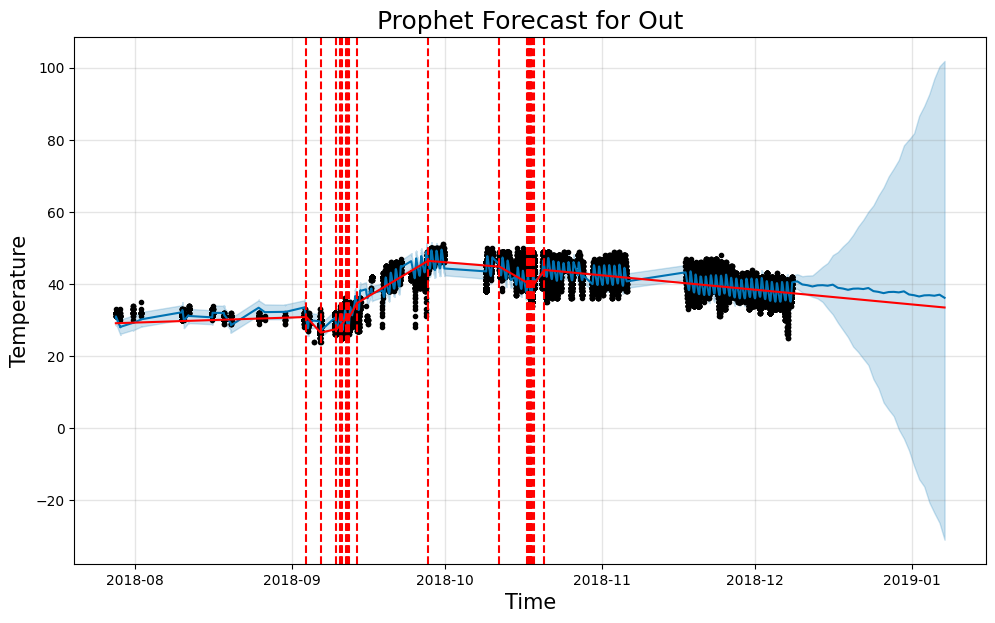

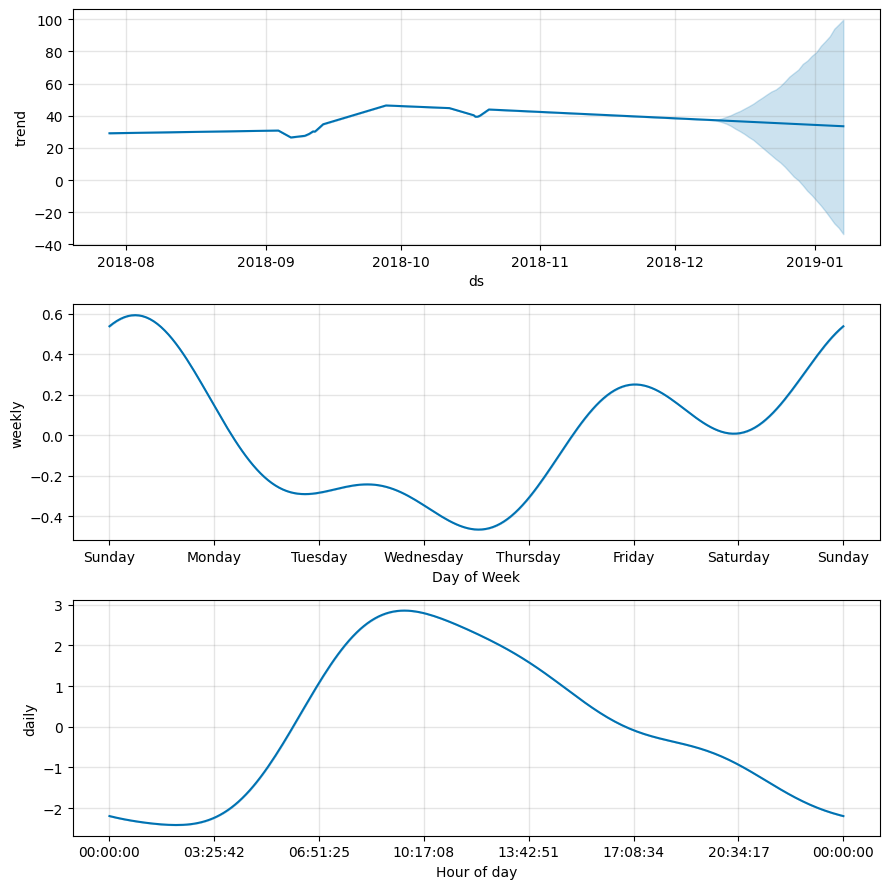

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-07-28 07:07:00,29.122955,28.468934,32.624954,29.122955,29.122955,1.484296,1.484296,1.484296,1.390845,1.390845,1.390845,0.093451,0.093451,0.093451,0.0,0.0,0.0,30.607251
1,2018-07-28 07:08:00,29.122987,28.560976,32.511252,29.122987,29.122987,1.503763,1.503763,1.503763,1.409969,1.409969,1.409969,0.093794,0.093794,0.093794,0.0,0.0,0.0,30.626750
2,2018-07-28 07:09:00,29.123020,28.737739,32.624635,29.123020,29.123020,1.523143,1.523143,1.523143,1.429005,1.429005,1.429005,0.094138,0.094138,0.094138,0.0,0.0,0.0,30.646162
3,2018-07-28 07:14:00,29.123182,28.782070,32.697253,29.123182,29.123182,1.618672,1.618672,1.618672,1.522807,1.522807,1.522807,0.095865,0.095865,0.095865,0.0,0.0,0.0,30.741854
4,2018-07-28 07:15:00,29.123214,28.765141,32.808435,29.123214,29.123214,1.637495,1.637495,1.637495,1.541282,1.541282,1.541282,0.096213,0.096213,0.096213,0.0,0.0,0.0,30.760709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22630,2019-01-03 09:29:00,34.010462,-16.155695,89.347661,-19.255978,86.362573,2.833823,2.833823,2.833823,2.851264,2.851264,2.851264,-0.017441,-0.017441,-0.017441,0.0,0.0,0.0,36.844284
22631,2019-01-04 09:29:00,33.878212,-20.561594,92.660426,-23.018877,89.461859,3.014948,3.014948,3.014948,2.851264,2.851264,2.851264,0.163684,0.163684,0.163684,0.0,0.0,0.0,36.893160
22632,2019-01-05 09:29:00,33.745962,-23.493191,96.985036,-26.881170,94.134232,2.998973,2.998973,2.998973,2.851264,2.851264,2.851264,0.147709,0.147709,0.147709,0.0,0.0,0.0,36.744935
22633,2019-01-06 09:29:00,33.613712,-26.215993,100.327496,-29.708443,96.867107,3.421530,3.421530,3.421530,2.851264,2.851264,2.851264,0.570266,0.570266,0.570266,0.0,0.0,0.0,37.035242


In [40]:
run_prophet('Out',30)

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

# 7. Conclusion
><div class="alert alert-success" role="alert">
><ul>
><li>ID column was not used as useful information, but it was used as a unique identifier for each row.</li>
><li>We got some useful information such as <b>seasonal information or timing information</b> for analysis from datetime column.</li>
><li>Inside temperature is composed of a single distribution, <u>while outside temperature is composed of multiple distributions.</u></li>
><li>Outside temperature can be <u>more affected by seasonal temperature fluctuations</u> than inside temperature.</li>
><li>So many drops in the data made it difficult to build model, so interpolating daily-mean data by 'spline' method worked.</li>
><li>Some outliers made it difficult to build forecasting model, but thanks to Prophet it is thought we built robust model against outliers.</li>
></ul>
></div>

## Task Submission
>Through the EDA & Modeling above, we can answer [several tasks](https://www.kaggle.com/atulanandjha/temperature-readings-iot-devices/tasks).

### How outside temp was related to inside temp ?
><div class="alert alert-info" role="alert">
>Answer :
><ul>
><li>Outside temperature is composed of <b>multiple distribution</b>, while inside temperature has single distribution.</li>
><li>Inside temperature has flat trend, but <u>outside temperature has the trend that is seemed to be affected by time-series factor such as seasonality.</u></li>
></ul>
></div>

In [41]:
dist = (hv.Distribution(df[df['place']=='In']['temp'], label='In') * hv.Distribution(df[df['place']=='Out']['temp'], label='Out'))\
                                .opts(title="Temperature by Place Distribution", xlabel="Temperature", ylabel="Density",tools=['hover'],show_grid=True, fontsize={'title':11})
tsdf['daily'] = tsdf['date'].apply(lambda x : pd.to_datetime(x.strftime('%Y-%m-%d')))
in_day = tsdf[tsdf['place']=='In'].groupby(['daily']).agg({'temp':['mean']})
in_day.columns = [f"{i[0]}_{i[1]}" for i in in_day.columns]
out_day = tsdf[tsdf['place']=='Out'].groupby(['daily']).agg({'temp':['mean']})
out_day.columns = [f"{i[0]}_{i[1]}" for i in out_day.columns]
curve = (hv.Curve(in_day, label='In') * hv.Curve(out_day, label='Out')).opts(title="Daily Temperature Mean", ylabel="Temperature", xlabel='Day', shared_axes=False,tools=['hover'],show_grid=True)
(dist + curve).opts(width=400, height=300)

:Layout
   .Overlay.I  :Overlay
      .Distribution.In  :Distribution   [temp]   (Density)
      .Distribution.Out :Distribution   [temp]   (Density)
   .Overlay.II :Overlay
      .Curve.In  :Curve   [daily]   (temp_mean)
      .Curve.Out :Curve   [daily]   (temp_mean)

### variance of temp for inside - outside room temp ?
><div class="alert alert-info" role="alert">
>Answer :
><ul>
><li>As shown below, <u>outside temperature has larger variance</u> than inside temperature.</li>
></ul>
></div>

In [42]:
in_var = hv.Violin(org_df['In'].values, vdims='Temperature').opts(title="In Temperature Variance", box_color='red')
out_var = hv.Violin(org_df['Out'].values, vdims='Temperature').opts(title="Out Temperature Variance", box_color='blue')
(in_var + out_var).opts(opts.Violin(width=400, height=300,show_grid=True))

:Layout
   .Violin.I  :Violin   (Temperature)
   .Violin.II :Violin   (Temperature)

### Predict the next scenario?
><div class="alert alert-info" role="alert">
>Answer :
><ul>
><li>We built the forecasting model by using <b>Prophet</b>.</li>
><li>Predicting next 30 points(about a month), it looks that the model generated future points at a certain accuracy.</li>
></ul>
></div>

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


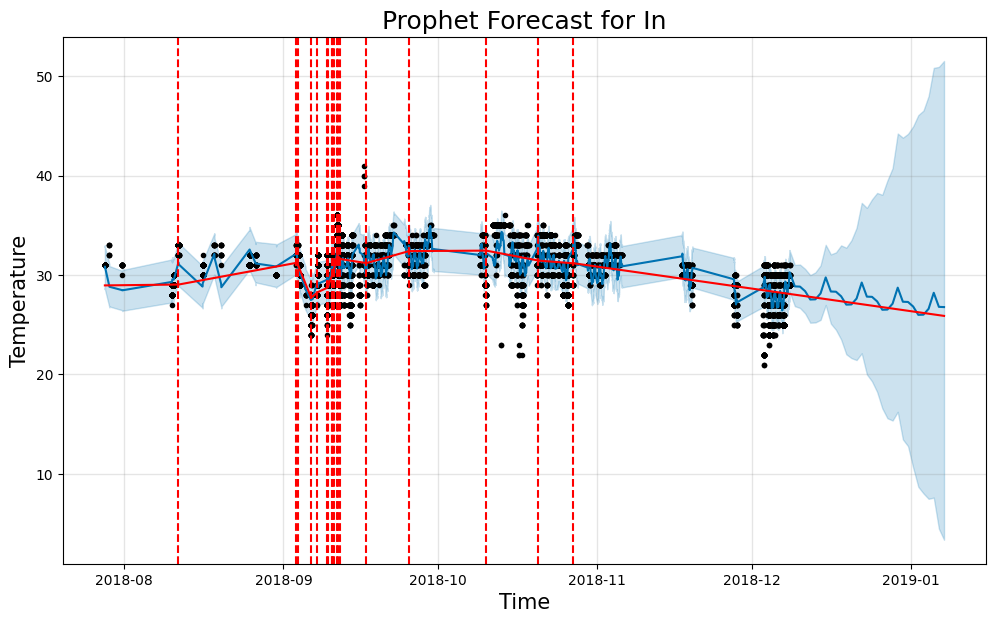

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.


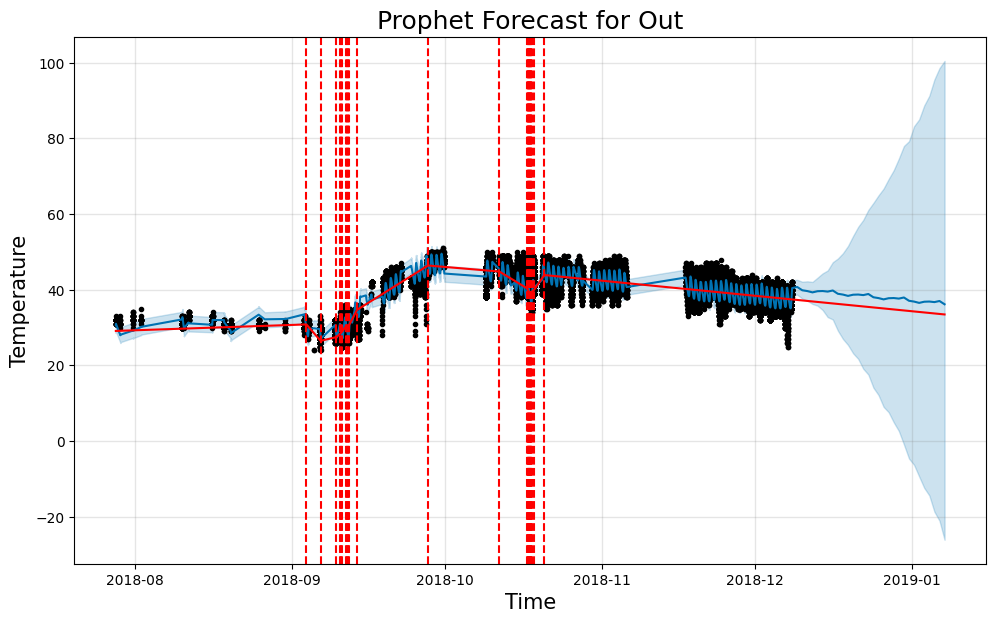

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,daily_lower,daily_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-07-28 07:07:00,29.122955,28.587102,32.612692,29.122955,29.122955,1.484296,1.484296,1.484296,1.390845,1.390845,1.390845,0.093451,0.093451,0.093451,0.0,0.0,0.0,30.607251
1,2018-07-28 07:08:00,29.122987,28.620124,32.594173,29.122987,29.122987,1.503763,1.503763,1.503763,1.409969,1.409969,1.409969,0.093794,0.093794,0.093794,0.0,0.0,0.0,30.626750
2,2018-07-28 07:09:00,29.123020,28.601839,32.578885,29.123020,29.123020,1.523143,1.523143,1.523143,1.429005,1.429005,1.429005,0.094138,0.094138,0.094138,0.0,0.0,0.0,30.646162
3,2018-07-28 07:14:00,29.123182,28.700249,32.650913,29.123182,29.123182,1.618672,1.618672,1.618672,1.522807,1.522807,1.522807,0.095865,0.095865,0.095865,0.0,0.0,0.0,30.741854
4,2018-07-28 07:15:00,29.123214,28.749459,32.924265,29.123214,29.123214,1.637495,1.637495,1.637495,1.541282,1.541282,1.541282,0.096213,0.096213,0.096213,0.0,0.0,0.0,30.760709
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22630,2019-01-03 09:29:00,34.010462,-12.359951,88.715851,-15.180329,85.759901,2.833823,2.833823,2.833823,2.851264,2.851264,2.851264,-0.017441,-0.017441,-0.017441,0.0,0.0,0.0,36.844284
22631,2019-01-04 09:29:00,33.878212,-14.354381,91.259028,-17.586596,89.072418,3.014948,3.014948,3.014948,2.851264,2.851264,2.851264,0.163684,0.163684,0.163684,0.0,0.0,0.0,36.893160
22632,2019-01-05 09:29:00,33.745962,-18.645999,95.567967,-21.720631,92.332357,2.998973,2.998973,2.998973,2.851264,2.851264,2.851264,0.147709,0.147709,0.147709,0.0,0.0,0.0,36.744935
22633,2019-01-06 09:29:00,33.613712,-21.025253,98.581132,-24.580043,95.199520,3.421530,3.421530,3.421530,2.851264,2.851264,2.851264,0.570266,0.570266,0.570266,0.0,0.0,0.0,37.035242


In [43]:
run_prophet('In',30, False)
run_prophet('Out',30, False)

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>

# 8. References
>* **Good Pre-processing & EDA notebook**  
>https://www.kaggle.com/satishkundanagar/temp-reading-iot-devices-eda
>* **Prophet Document**  
>https://facebook.github.io/prophet/docs/quick_start.html
>* **Prophet Introduction Paper**  
>https://peerj.com/preprints/3190.pdf
>* **IOT-TEMP-DATA**
>https://www.kaggle.com/code/koheimuramatsu/iot-temperature-forecasting?select=IOT-temp.csv

<a href="#top" class="btn btn-success btn-sm active" role="button" aria-pressed="true" style="color:white;">Table of Contents</a>